<a href="https://colab.research.google.com/github/rodrigocastillo69/Deep-learning-Vision/blob/main/Unidad1/Proyectito1/Mini_proy_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Proyecto Unidad 1: Clasificación en CIFAR-10 con ResNet y EfficientNet

* Pipeline completo de clasificación con CNN (ResNet o EfficientNet) sobre CIFAR-10 (Partes 1 a 5)
* Comparativa técnica de dos arquitecturas CNN con curvas de aprendizaje y métricas (Partes 5 y 6)
*Reporte de diseño (arquitectura, hiperparámetros, estrategia de entrenamiento) (Parte 7)

### Recomendación de entorno

Activen GPU en Colab: **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**. ResNet-18 y EfficientNet-B0 a resolución 224×224 son considerablemente más pesados que la CNN pequeña de la práctica anterior; en CPU van a funcionar, pero mucho más lento. Las constantes `TAM_TRAIN`, `TAM_VAL` y `N_EPOCAS` están pensadas para ajustarse según el tiempo y el hardware disponible.


## 0. Configuración inicial

In [1]:
!pip install -q torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 3.9 MB/s eta 0:00:00


In [2]:
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import pandas as pd

from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall,
    MulticlassF1Score,
    MulticlassConfusionMatrix,
)

SEMILLA = 42
torch.manual_seed(SEMILLA)

DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DISPOSITIVO)

Dispositivo: cuda


---
## 1. Datos: CIFAR-10 a 224x224

ResNet y EfficientNet, tal como se definen en `torchvision.models`, esperan entradas de 224x224 pixeles (el tamano estandar de ImageNet en el que se disenaron y evaluaron originalmente). Redimensionamos CIFAR-10 (32x32 nativo) a ese tamano.


In [3]:
MEDIA_IMAGENET = (0.485, 0.456, 0.406)
STD_IMAGENET = (0.229, 0.224, 0.225)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEDIA_IMAGENET, STD_IMAGENET),
])

# Carga de CIFAR-10 (entrenamiento y prueba)
trainset_completo = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Subconjuntos de entrenamiento y validacion (ajustables segun el hardware).
# Con GPU (T4): 5,000 imagenes de entrenamiento es un buen balance tiempo/resultado.
TAM_TRAIN = 5000
TAM_VAL = 1000

# Mezcla reproducible: ambos modelos usaran EXACTAMENTE estos mismos indices.
generador = torch.Generator().manual_seed(SEMILLA)
indices = torch.randperm(len(trainset_completo), generator=generador).tolist()
train_subset = Subset(trainset_completo, indices[:TAM_TRAIN])
val_subset = Subset(trainset_completo, indices[TAM_TRAIN:TAM_TRAIN + TAM_VAL])  # sin traslape con train

nombres_clases = trainset_completo.classes
print("Clases:", nombres_clases)
print("Tamano del set de entrenamiento completo:", len(trainset_completo))
print("Tamano del set de prueba:", len(testset))

100%|██████████| 170M/170M [00:51<00:00, 3.29MB/s]


Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Tamano del set de entrenamiento completo: 50000
Tamano del set de prueba: 10000


### 1.1 Subconjuntos de trabajo

Del set de entrenamiento original (50,000 imágenes) tomamos un subconjunto aleatorio de **5,000 imágenes para entrenar** y otro, sin traslape, de **1,000 para validar**. La semilla fija (`SEMILLA = 42`) garantiza que ambos modelos usen exactamente los mismos datos. El conjunto de **prueba** es el oficial de CIFAR-10 completo (10,000 imágenes), que no se usa durante el entrenamiento.

Entrenamiento: 5000 imagenes  |  Validacion: 1000  |  Prueba: 10000


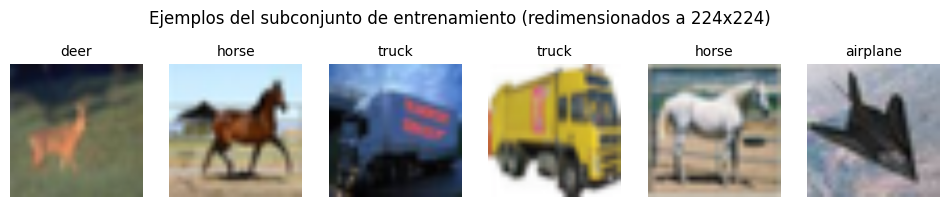

In [4]:
BATCH_SIZE = 32
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print(f"Entrenamiento: {len(train_subset)} imagenes  |  Validacion: {len(val_subset)}  |  Prueba: {len(testset)}")


def desnormalizar(img_tensor):
    """Invierte la normalizacion para poder visualizar la imagen."""
    media = torch.tensor(MEDIA_IMAGENET).view(3, 1, 1)
    std = torch.tensor(STD_IMAGENET).view(3, 1, 1)
    return (img_tensor * std + media).clamp(0, 1)


imagenes, etiquetas = next(iter(train_loader))
fig, axs = plt.subplots(1, 6, figsize=(12, 2.5))
for i, ax in enumerate(axs):
    ax.imshow(desnormalizar(imagenes[i]).permute(1, 2, 0))
    ax.set_title(nombres_clases[etiquetas[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("Ejemplos del subconjunto de entrenamiento (redimensionados a 224x224)")
plt.show()


---
## 2. Construir ResNet-18 y EfficientNet-B0

Tomamos las arquitecturas de `torchvision.models` con pesos preentrenados en ImageNet (`weights="DEFAULT"`) y adaptamos unicamente la ultima capa para que clasifique entre las 10 clases de CIFAR-10 en vez de las 1000 de ImageNet — el resto de la arquitectura, y sus pesos preentrenados, se conservan exactamente como en 1.3.

Ver : https://docs.pytorch.org/vision/main/models.html


Ejemplo: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html


In [5]:
def construir_resnet18(n_clases=10):
    """ResNet-18 oficial de torchvision; solo se reemplaza la ultima capa (fc)."""
    modelo = models.resnet18(weights="DEFAULT")
    modelo.fc = nn.Linear(modelo.fc.in_features, n_clases)
    return modelo


def construir_efficientnet_b0(n_clases=10):
    """EfficientNet-B0 oficial de torchvision; solo se reemplaza la ultima capa (classifier[1])."""
    modelo = models.efficientnet_b0(weights="DEFAULT")
    modelo.classifier[1] = nn.Linear(modelo.classifier[1].in_features, n_clases)
    return modelo


def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters())


# Misma semilla antes de construir cada modelo (la capa nueva se inicializa de forma reproducible)
torch.manual_seed(SEMILLA)
modelo_resnet = construir_resnet18(10)
torch.manual_seed(SEMILLA)
modelo_efficientnet = construir_efficientnet_b0(10)

params_resnet = contar_parametros(modelo_resnet)
params_efficientnet = contar_parametros(modelo_efficientnet)

print("Ultima capa ResNet-18      :", modelo_resnet.fc)
print("Ultima capa EfficientNet-B0:", modelo_efficientnet.classifier[1])
print(f"\nParametros ResNet-18      : {params_resnet:,}")
print(f"Parametros EfficientNet-B0: {params_efficientnet:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 115MB/s] 


Ultima capa ResNet-18      : Linear(in_features=512, out_features=10, bias=True)
Ultima capa EfficientNet-B0: Linear(in_features=1280, out_features=10, bias=True)

Parametros ResNet-18      : 11,181,642
Parametros EfficientNet-B0: 4,020,358


---
## 3. Metricas con TorchMetrics

Mismo patron que en la Practica 4 original: `update()` por lote, `compute()` al final de la epoca, `reset()` antes de la siguiente. Usamos `average="macro"` (promedio simple entre las 10 clases)

ver: https://meta-pytorch.org/torcheval/main/torcheval.metrics.html

Ejemplo :  
"accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),



In [11]:
def crear_metricas(n_clases=10):
    return {
         #Completar
        "accuracy": MulticlassAccuracy(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "precision": MulticlassPrecision(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "recall": MulticlassRecall(num_classes=n_clases, average="macro").to(DISPOSITIVO),
        "f1": MulticlassF1Score(num_classes=n_clases, average="macro").to(DISPOSITIVO),
    }


def correr_epoca(modelo, loader, perdida_fn, metricas, optimizador=None):
    """
    Corre una epoca completa. Si optimizador no es None, entrena (backward + step);
    si es None, solo evalua (torch.no_grad()).
    """
    modo_entrenamiento = optimizador is not None
    modelo.train() if modo_entrenamiento else modelo.eval()

    for m in metricas.values():
        m.reset()

    perdida_acumulada, n_lotes = 0.0, 0
    contexto = torch.enable_grad() if modo_entrenamiento else torch.no_grad()

    with contexto:
        for imagenes, etiquetas in loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)

            if modo_entrenamiento:
                optimizador.zero_grad()

            salida = modelo(imagenes)
            perdida = perdida_fn(salida, etiquetas)

            if modo_entrenamiento:
                perdida.backward()
                optimizador.step()

            perdida_acumulada += perdida.item()
            n_lotes += 1

            preds = salida.argmax(dim=1)
            for m in metricas.values():
                m.update(preds, etiquetas)

    resultados = {nombre: m.compute().item() for nombre, m in metricas.items()}
    resultados["loss"] = perdida_acumulada / n_lotes
    return resultados


---
## 4. Entrenar ambos modelos en igualdad de condiciones

Para que la comparacion sea tecnicamente valida, ambos modelos usan **los mismos datos, el mismo numero de epocas, el mismo optimizador y el mismo learning rate**. Documentamos estos hiperparametros aqui porque los vamos a necesitar tal cual para el reporte (Parte 7).


In [12]:
# Hiperparametros IDENTICOS para ambos modelos
N_EPOCAS = 5
LR = 1e-4
OPTIMIZADOR = "Adam"
# BATCH_SIZE = 32 (definido en la seccion 1) | TAM_TRAIN = 5000 | TAM_VAL = 1000 | pesos: ImageNet

def entrenar_modelo(modelo, nombre, n_epocas=N_EPOCAS, lr=LR):
    """Entrena un modelo y devuelve el historial (loss, metricas y duracion por epoca) como DataFrame."""
    torch.manual_seed(SEMILLA)  # mismo orden de lotes para ambos modelos
    modelo = modelo.to(DISPOSITIVO)
    perdida_fn = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=lr)
    met_train, met_val = crear_metricas(), crear_metricas()

    filas = []
    for epoca in range(1, n_epocas + 1):
        t0 = time.time()
        tr = correr_epoca(modelo, train_loader, perdida_fn, met_train, optimizador)
        va = correr_epoca(modelo, val_loader, perdida_fn, met_val)
        if DISPOSITIVO.type == "cuda":
            torch.cuda.synchronize()
        duracion = time.time() - t0

        filas.append({
            "epoca": epoca,
            "train_loss": tr["loss"], "val_loss": va["loss"],
            "train_acc": tr["accuracy"], "val_acc": va["accuracy"],
            "train_f1": tr["f1"], "val_f1": va["f1"],
            "duracion_s": duracion,
        })
        print(f"[{nombre}] epoca {epoca}/{n_epocas} | "
              f"loss {tr['loss']:.3f}/{va['loss']:.3f} | "
              f"acc {tr['accuracy']:.3f}/{va['accuracy']:.3f} | {duracion:.1f}s")
    return pd.DataFrame(filas)


historial_resnet = entrenar_modelo(modelo_resnet, "ResNet-18")
historial_efficientnet = entrenar_modelo(modelo_efficientnet, "EfficientNet-B0")

[ResNet-18] epoca 1/5 | loss 0.031/0.415 | acc 0.993/0.871 | 19.7s
[ResNet-18] epoca 2/5 | loss 0.036/0.390 | acc 0.990/0.881 | 19.1s
[ResNet-18] epoca 3/5 | loss 0.034/0.532 | acc 0.990/0.861 | 20.0s
[ResNet-18] epoca 4/5 | loss 0.028/0.455 | acc 0.994/0.871 | 18.7s
[ResNet-18] epoca 5/5 | loss 0.027/0.423 | acc 0.992/0.877 | 19.7s
[EfficientNet-B0] epoca 1/5 | loss 0.066/0.276 | acc 0.980/0.921 | 28.1s
[EfficientNet-B0] epoca 2/5 | loss 0.027/0.333 | acc 0.994/0.908 | 28.1s
[EfficientNet-B0] epoca 3/5 | loss 0.017/0.307 | acc 0.997/0.920 | 28.0s
[EfficientNet-B0] epoca 4/5 | loss 0.016/0.303 | acc 0.997/0.932 | 28.0s
[EfficientNet-B0] epoca 5/5 | loss 0.016/0.319 | acc 0.997/0.923 | 29.1s


In [13]:
print("Historial ResNet-18")
display(historial_resnet.round(4))
print("Historial EfficientNet-B0")
display(historial_efficientnet.round(4))

Historial ResNet-18


,epoca,train_loss,val_loss,train_acc,val_acc,train_f1,val_f1,duracion_s
0,1,0.0305,0.4152,0.9931,0.8710,0.9931,0.8699,19.6793
1,2,0.0356,0.3897,0.9902,0.8807,0.9903,0.8789,19.0879
2,3,0.0342,0.5321,0.9898,0.8607,0.9899,0.8584,20.0335
3,4,0.0284,0.4550,0.9937,0.8712,0.9937,0.8683,18.6779
4,5,0.0271,0.4232,0.9919,0.8774,0.9919,0.8773,19.7266


Historial EfficientNet-B0


,epoca,train_loss,val_loss,train_acc,val_acc,train_f1,val_f1,duracion_s
0,1,0.0662,0.2760,0.9804,0.9210,0.9804,0.9204,28.0846
1,2,0.0265,0.3330,0.9937,0.9075,0.9937,0.9058,28.0813
2,3,0.0170,0.3073,0.9973,0.9200,0.9974,0.9189,27.9865
3,4,0.0162,0.3032,0.9968,0.9324,0.9968,0.9320,28.0411
4,5,0.0159,0.3193,0.9974,0.9235,0.9974,0.9222,29.0586


---
## 5. Curvas de aprendizaje: ResNet-18 vs. EfficientNet-B0

Mismo diagnostico que en 1.4: comparen el gap train/val de cada modelo, y ahora tambien comparenlos *entre si* — ¿cual generaliza mejor con el mismo presupuesto de datos y epocas?


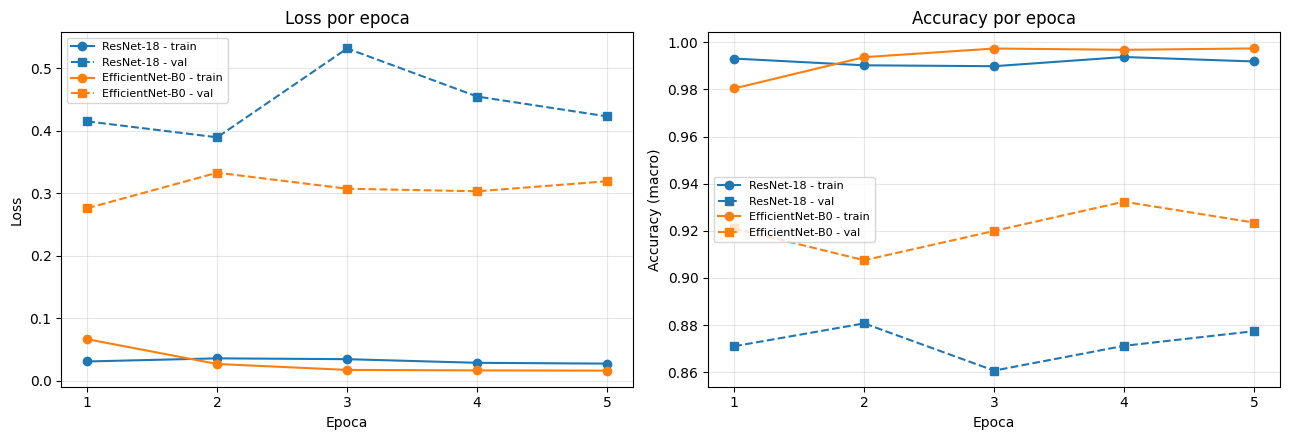

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
estilos = [(historial_resnet, "ResNet-18", "tab:blue"), (historial_efficientnet, "EfficientNet-B0", "tab:orange")]

for h, nombre, color in estilos:
    axs[0].plot(h["epoca"], h["train_loss"], "-o", color=color, label=f"{nombre} - train")
    axs[0].plot(h["epoca"], h["val_loss"], "--s", color=color, label=f"{nombre} - val")
    axs[1].plot(h["epoca"], h["train_acc"], "-o", color=color, label=f"{nombre} - train")
    axs[1].plot(h["epoca"], h["val_acc"], "--s", color=color, label=f"{nombre} - val")

axs[0].set_title("Loss por epoca"); axs[0].set_ylabel("Loss")
axs[1].set_title("Accuracy por epoca"); axs[1].set_ylabel("Accuracy (macro)")
for ax in axs:
    ax.set_xlabel("Epoca"); ax.set_xticks(historial_resnet["epoca"]); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## 6. Reporte final sobre el set de prueba

Evaluamos ambos modelos sobre las 10,000 imagenes de prueba de CIFAR-10


In [15]:
def evaluar_en_prueba(modelo, nombre_modelo):
    metrica_acc = MulticlassAccuracy(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_prec = MulticlassPrecision(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_rec = MulticlassRecall(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_f1 = MulticlassF1Score(num_classes=10, average="macro").to(DISPOSITIVO)
    metrica_matriz = MulticlassConfusionMatrix(num_classes=10).to(DISPOSITIVO)

    modelo.eval()
    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes, etiquetas = imagenes.to(DISPOSITIVO), etiquetas.to(DISPOSITIVO)
            preds = modelo(imagenes).argmax(dim=1)
            for m in [metrica_acc, metrica_prec, metrica_rec, metrica_f1, metrica_matriz]:
                m.update(preds, etiquetas)

    resumen = {
        "modelo": nombre_modelo,
        "accuracy": metrica_acc.compute().item(),
        "precision": metrica_prec.compute().item(),
        "recall": metrica_rec.compute().item(),
        "f1": metrica_f1.compute().item(),
    }
    return resumen, metrica_matriz.compute().cpu().numpy()


resumen_resnet, matriz_resnet = evaluar_en_prueba(modelo_resnet, "ResNet-18")
resumen_efficientnet, matriz_efficientnet = evaluar_en_prueba(modelo_efficientnet, "EfficientNet-B0")

df_comparativa = pd.DataFrame([resumen_resnet, resumen_efficientnet]).round(3)
df_comparativa


,modelo,accuracy,precision,recall,f1
0,ResNet-18,0.875,0.877,0.875,0.875
1,EfficientNet-B0,0.919,0.919,0.919,0.918


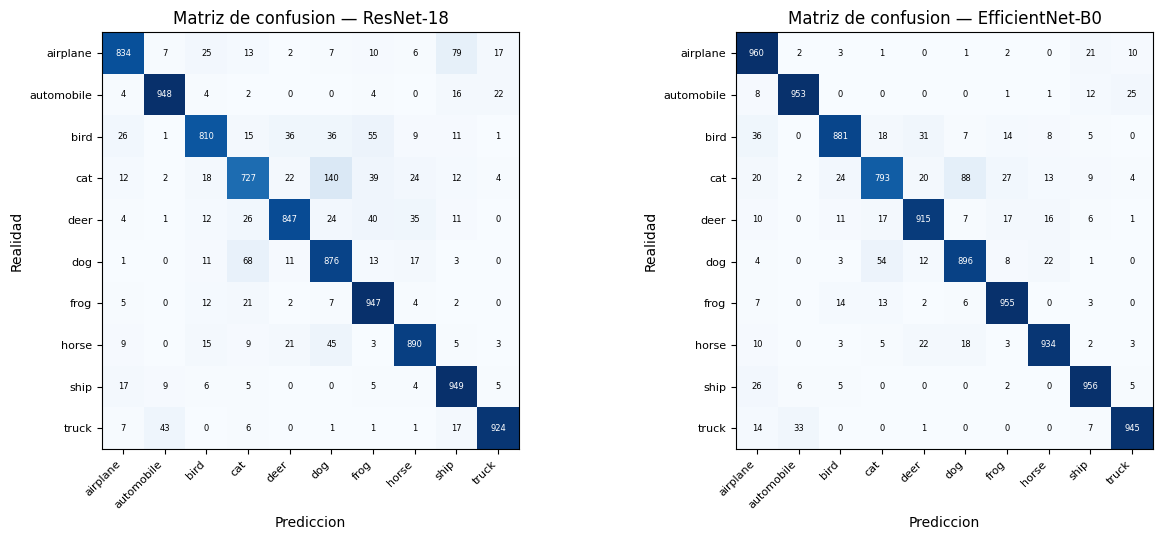

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, matriz, nombre in [(axs[0], matriz_resnet, "ResNet-18"), (axs[1], matriz_efficientnet, "EfficientNet-B0")]:
    im = ax.imshow(matriz, cmap="Blues")
    ax.set_xticks(range(10)); ax.set_xticklabels(nombres_clases, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(nombres_clases, fontsize=8)
    ax.set_xlabel("Prediccion"); ax.set_ylabel("Realidad")
    ax.set_title(f"Matriz de confusion — {nombre}")
    for i in range(10):
        for j in range(10):
            color = "white" if matriz[i, j] > matriz.max() / 2 else "black"
            ax.text(j, i, str(int(matriz[i, j])), ha="center", va="center", color=color, fontsize=6)

plt.tight_layout()
plt.show()


In [17]:
def par_mas_confundido(matriz, nombres):
    """Devuelve (real, predicha, conteo) de la celda fuera de la diagonal con mas errores."""
    m = matriz.copy()
    for i in range(len(m)):
        m[i, i] = 0
    i, j = divmod(int(m.argmax()), m.shape[1])
    return nombres[i], nombres[j], int(m[i, j])

for nombre, matriz in [("ResNet-18", matriz_resnet), ("EfficientNet-B0", matriz_efficientnet)]:
    real, pred, n = par_mas_confundido(matriz, nombres_clases)
    print(f"{nombre}: mayor confusion -> real '{real}' predicha como '{pred}' ({n} imagenes)")

ResNet-18: mayor confusion -> real 'cat' predicha como 'dog' (140 imagenes)
EfficientNet-B0: mayor confusion -> real 'cat' predicha como 'dog' (88 imagenes)


---
## 7. Reporte de diseño


In [18]:
from IPython.display import Markdown, display

# Datos de apoyo
res = {"ResNet-18": resumen_resnet, "EfficientNet-B0": resumen_efficientnet}
hist = {"ResNet-18": historial_resnet, "EfficientNet-B0": historial_efficientnet}
pars = {"ResNet-18": params_resnet, "EfficientNet-B0": params_efficientnet}
mats = {"ResNet-18": matriz_resnet, "EfficientNet-B0": matriz_efficientnet}

hardware = (f"GPU ({torch.cuda.get_device_name(0)})" if DISPOSITIVO.type == "cuda" else "CPU")
mejor = max(res, key=lambda k: res[k]["f1"])
otro = [k for k in res if k != mejor][0]


def diagnostico(h):
    """Reglas simples sobre la ultima epoca y la tendencia de val_loss."""
    u = h.iloc[-1]
    gap = u["train_acc"] - u["val_acc"]
    sube_val_loss = (h["val_loss"].iloc[-1] > h["val_loss"].min() + 0.02) and len(h) >= 3
    if u["train_acc"] < 0.70 and u["val_acc"] < 0.70:
        tipo = "**subajuste (underfitting)**: ambos accuracies son bajos"
    elif gap > 0.08 or (sube_val_loss and gap > 0.03):
        tipo = "**posible sobreajuste (overfitting)**: la brecha train/val es grande o la val_loss vuelve a subir"
    else:
        tipo = "**ajuste saludable**: train y validacion convergen juntas con una brecha pequena"
    return (f"{tipo}. Evidencia: train_acc={u['train_acc']:.3f}, val_acc={u['val_acc']:.3f} "
            f"(brecha {gap:+.3f}); train_loss={u['train_loss']:.3f}, val_loss={u['val_loss']:.3f} "
            f"(val_loss minima {h['val_loss'].min():.3f} en la epoca {int(h['val_loss'].idxmin()) + 1}).")


explic = {
    frozenset(["cat", "dog"]): "ambos son mamiferos cuadrupedos de tamano, textura de pelo y poses parecidas, y a baja resolucion (32x32 reescalado) sus rasgos distintivos se pierden.",
    frozenset(["automobile", "truck"]): "ambos son vehiculos terrestres con ruedas y carroceria similar; la diferencia principal es el tamano, que no es evidente en una imagen recortada.",
    frozenset(["deer", "horse"]): "son animales de cuatro patas, de silueta y colores parecidos, normalmente fotografiados sobre pasto o campo.",
    frozenset(["airplane", "ship"]): "comparten fondos azules (cielo/mar) y siluetas alargadas sobre un horizonte.",
    frozenset(["airplane", "bird"]): "ambos aparecen contra el cielo, con alas extendidas y fondo uniforme.",
    frozenset(["bird", "frog"]): "pueden compartir tamano pequeno, fondos naturales y colores verdes/pardos.",
    frozenset(["cat", "frog"]): "formas redondeadas y fondos de interior/naturaleza parecidos a baja resolucion.",
    frozenset(["dog", "horse"]): "son animales cuadrupedos fotografiados en exteriores con proporciones similares.",
    frozenset(["bird", "deer"]): "ambos suelen aparecer sobre fondos naturales verdes o cafes.",
    frozenset(["automobile", "ship"]): "siluetas alargadas con superficies metalicas y colores similares.",
    frozenset(["truck", "ship"]): "objetos grandes y rectangulares con superficies metalicas.",
}
def explicar(a, b):
    return explic.get(frozenset([a, b]),
        "las dos clases comparten rasgos visuales de forma, color o fondo que, a 32x32 reescalado, el modelo no logra separar bien.")


t = df_comparativa.set_index("modelo")
dur = {k: hist[k]["duracion_s"] for k in hist}

# ---------- 1 ----------
p1 = (f"**1. Arquitectura recomendada.** Con base en el set de prueba, recomendamos **{mejor}**: "
      f"obtuvo accuracy={res[mejor]['accuracy']:.3f}, precision={res[mejor]['precision']:.3f}, "
      f"recall={res[mejor]['recall']:.3f} y F1={res[mejor]['f1']:.3f}, frente a F1={res[otro]['f1']:.3f} de {otro} "
      f"(diferencia de {abs(res[mejor]['f1'] - res[otro]['f1']):.3f} en F1). "
      f"Ademas, {mejor} tardo en promedio {dur[mejor].mean():.1f} s por epoca frente a {dur[otro].mean():.1f} s de {otro}.")

# ---------- 2 ----------
p2 = (f"**2. Hiperparametros.** Learning rate: `{LR}` · Optimizador: `{OPTIMIZADOR}` · Epocas: `{N_EPOCAS}` · "
      f"Batch size: `{BATCH_SIZE}` (entrenamiento y validacion; prueba usa 64) · Subconjunto de entrenamiento: `{TAM_TRAIN}` imagenes "
      f"(validacion: `{TAM_VAL}`; prueba: `{len(testset)}`) · Funcion de perdida: `CrossEntropyLoss` · "
      f"Pesos preentrenados: **si** (ImageNet, `weights=\"DEFAULT\"`, normalizacion con media/desv. de ImageNet) · "
      f"Entrada: 224x224 · Semilla: `{SEMILLA}`.")

# ---------- 3 ----------
tiempos = "; ".join(f"{k}: " + ", ".join(f"{x:.1f}" for x in dur[k]) + f" s (promedio {dur[k].mean():.1f} s)" for k in hist)
p3 = f"**3. Hardware y duracion por epoca.** Se entreno en **{hardware}**. Duracion por epoca (epocas 1 a {N_EPOCAS}) -> {tiempos}."

# ---------- 4 ----------
p4 = ("**4. Diagnostico de las curvas.**\n"
      + "\n".join(f"   - **{k}**: {diagnostico(hist[k])}" for k in hist))

# ---------- 5 ----------
def eficiencia(k): return res[k]["f1"] / (pars[k] / 1e6)
menos = min(pars, key=pars.get); mas = max(pars, key=pars.get)
p5 = (f"**5. Capacidad vs. eficiencia.** {mas} tiene {pars[mas]/1e6:.2f} M de parametros y {menos} {pars[menos]/1e6:.2f} M "
      f"({pars[mas]/pars[menos]:.1f}x menos). Sus F1 en prueba son {res[mas]['f1']:.3f} ({mas}) y {res[menos]['f1']:.3f} ({menos}). "
      f"En F1 por millon de parametros: ResNet-18 = {eficiencia('ResNet-18'):.3f} y EfficientNet-B0 = {eficiencia('EfficientNet-B0'):.3f}. ")
if res[menos]["f1"] >= res[mas]["f1"] - 0.005:
    p5 += f"Es decir, {menos} logra un desempeno igual o mejor con bastantes menos parametros: mejor relacion desempeno/costo; mas capacidad no se tradujo en mejores resultados en este experimento."
else:
    p5 += f"{mas} obtiene un F1 mayor gracias a su mayor capacidad, pero {menos} entrega la mayor parte del desempeno con una fraccion de los parametros, por lo que es mas eficiente por parametro."
p5 += " (Nota: el numero de parametros no equivale al tiempo de computo; ver duraciones por epoca en el punto 3.)"

# ---------- 6 ----------
lineas6 = []
for k in mats:
    real, pred, n = par_mas_confundido(mats[k], nombres_clases)
    lineas6.append(f"   - **{k}**: la mayor confusion es **{real} -> {pred}** ({n} imagenes de prueba). Razon: {explicar(real, pred)}")
p6 = "**6. Par de clases con mayor confusion.**\n" + "\n".join(lineas6)

display(Markdown("\n\n".join([p1, p2, p3, p4, p5, p6])))

**1. Arquitectura recomendada.** Con base en el set de prueba, recomendamos **EfficientNet-B0**: obtuvo accuracy=0.919, precision=0.919, recall=0.919 y F1=0.918, frente a F1=0.875 de ResNet-18 (diferencia de 0.044 en F1). Ademas, EfficientNet-B0 tardo en promedio 28.3 s por epoca frente a 19.4 s de ResNet-18.

**2. Hiperparametros.** Learning rate: `0.0001` · Optimizador: `Adam` · Epocas: `5` · Batch size: `32` (entrenamiento y validacion; prueba usa 64) · Subconjunto de entrenamiento: `5000` imagenes (validacion: `1000`; prueba: `10000`) · Funcion de perdida: `CrossEntropyLoss` · Pesos preentrenados: **si** (ImageNet, `weights="DEFAULT"`, normalizacion con media/desv. de ImageNet) · Entrada: 224x224 · Semilla: `42`.

**3. Hardware y duracion por epoca.** Se entreno en **GPU (Tesla T4)**. Duracion por epoca (epocas 1 a 5) -> ResNet-18: 19.7, 19.1, 20.0, 18.7, 19.7 s (promedio 19.4 s); EfficientNet-B0: 28.1, 28.1, 28.0, 28.0, 29.1 s (promedio 28.3 s).

**4. Diagnostico de las curvas.**
   - **ResNet-18**: **posible sobreajuste (overfitting)**: la brecha train/val es grande o la val_loss vuelve a subir. Evidencia: train_acc=0.992, val_acc=0.877 (brecha +0.114); train_loss=0.027, val_loss=0.423 (val_loss minima 0.390 en la epoca 2).
   - **EfficientNet-B0**: **posible sobreajuste (overfitting)**: la brecha train/val es grande o la val_loss vuelve a subir. Evidencia: train_acc=0.997, val_acc=0.923 (brecha +0.074); train_loss=0.016, val_loss=0.319 (val_loss minima 0.276 en la epoca 1).

**5. Capacidad vs. eficiencia.** ResNet-18 tiene 11.18 M de parametros y EfficientNet-B0 4.02 M (2.8x menos). Sus F1 en prueba son 0.875 (ResNet-18) y 0.918 (EfficientNet-B0). En F1 por millon de parametros: ResNet-18 = 0.078 y EfficientNet-B0 = 0.228. Es decir, EfficientNet-B0 logra un desempeno igual o mejor con bastantes menos parametros: mejor relacion desempeno/costo; mas capacidad no se tradujo en mejores resultados en este experimento. (Nota: el numero de parametros no equivale al tiempo de computo; ver duraciones por epoca en el punto 3.)

**6. Par de clases con mayor confusion.**
   - **ResNet-18**: la mayor confusion es **cat -> dog** (140 imagenes de prueba). Razon: ambos son mamiferos cuadrupedos de tamano, textura de pelo y poses parecidas, y a baja resolucion (32x32 reescalado) sus rasgos distintivos se pierden.
   - **EfficientNet-B0**: la mayor confusion es **cat -> dog** (88 imagenes de prueba). Razon: ambos son mamiferos cuadrupedos de tamano, textura de pelo y poses parecidas, y a baja resolucion (32x32 reescalado) sus rasgos distintivos se pierden.

---
## 8. Cierre y entregables del mini proyecto

### Checklist de entrega

- [ ] Notebook ejecutado de principio a fin, sin errores, con las celdas de ambos modelos corridas.
- [ ] Tabla comparativa final (Parte 6) con accuracy, precision, recall y F1 de ambos modelos.
- [ ] Graficas de curvas de entrenamiento (Parte 5) y matrices de confusion (Parte 6).
- [ ] Reporte de diseno (Parte 7) completado por el equipo.
- [ ] Hiperparametros documentados tal como quedaron configurados al momento de generar los resultados finales.


### Recursos citados

- Katanforoosh, K., & Ng, A. *Stanford CS230* — Section 8, "Advanced Evaluation Metrics". [cs230.stanford.edu/section/8](https://cs230.stanford.edu/section/8)
- TorchMetrics documentation — *Classification: Accuracy*. [torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html](https://torchmetrics.readthedocs.io/en/v0.9.1/classification/accuracy.html)
- Ultralytics. *Consejos y buenas practicas para entrenar modelos*. [docs.ultralytics.com/es/guides/model-training-tips](https://docs.ultralytics.com/es/guides/model-training-tips)
- He, K., Zhang, X., Ren, S., & Sun, J. (2015). Deep residual learning for image recognition. arXiv:1512.03385.
- Tan, M., & Le, Q. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. ICML 2019.
- Ayyadevara, K., & Reddy, Y. (2024). *Modern Computer Vision with PyTorch*. Packt Publishing.
